<img src="../img/htw-logo.png" width=150>


**I758 Wissens- und KI-basierte Systeme**

# Lineare Regression mit Kreuzvalidierung
Quelle: Kaggle  / Anpassungen CK
 

<font color="green"><b>KLAUSURTAUGLICH.</b></font>
Dieses Notebook gehört zu den fünf Notebooks, die Sie für die Klausur einreichen können. Bei vollständiger und korrekter Bearbeitung **erhalten Sie Punkte für die Abgabe, die zu Ihrer Klausur addiert werden.**

<span style="color:#FF5F00"><b>AUFGABE:</b></span><br>

Auch dieses Notebook enthält wieder eine Reihe von neuen Bibliotheken. Legen Sie eine neue virtuelle Umgebung an oder erweitern Sie die bestehende `ml-class`. Studieren Sie dazu die Import-Anweisungen.


Tipp: Vermutlich wird Ihr Leben einfacher, wenn Sie eine `requirements.txt` anlegen. Mehr dazu finden Sie z.B. in [diesem Post von Stackoverflow](https://stackoverflow.com/questions/66899666/how-to-install-from-requirements-txt) 



### Cross-Validation with Linear Regression

This notebook demonstrates how to do feature selection and cross-validation (CV) with linear regression as an example (it is heavily used in almost all modelling techniques such as decision trees, SVM etc.). We will mainly use `sklearn` to do cross-validation.

In [1]:
pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


### Explore the data

Let us first load and prepare the data.

In [2]:
# import all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import re

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import scale
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline

import warnings # supress warnings
warnings.filterwarnings('ignore')


In [3]:
# import Housing.csv
housing = pd.read_csv('data/Housing.csv', sep=";")
housing.head()


,price,area,garea,immo_score,build,ren,n_occ,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,8012,394,1932,2018,1,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,9429,907,1928,1921,4,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,10410,413,1973,1943,1,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,7725,860,2005,1981,2,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,8316,266,1937,2018,2,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
# number of samples 
len(housing.index)


545

For the first experiment, we'll do regression with only one feature, `area`, and we'll build a model to predict the price. Let's filter the data so it only contains `area` and `price`.

<span style="color:#FF5F00"><b>AUFGABE 1:</b></span><br>
Reduzieren Sie den Data Frame.
</div>

Nutzen Sie die Pandas-Funktion `loc[ , ]`, um `housing` auf die Spalten `area` und `price` zu reduzieren. Speichern Sie das Ergebnis in `df`. Der Befehl `df.head()` sollte im Anschluss einen Output wie im Bild liefern.

<img src="img/image_df_head.png">

In [5]:
# filter only area and price
df = housing.loc[:, ["area", "price"]]
df.head()


,area,price
0,7420,13300000
1,8960,12250000
2,9960,12250000
3,7500,12215000
4,7420,11410000


Scikit learn offers a wide variety of usefull *transformer* functions to scale, normalize and otherwise manipulate features.

<span style="color:#FF5F00"><b>AUFGABE 2:</b></span><br>

Skalieren Sie den Data Frame.
</div>

Nutzen Sie einen geeigneeten `Scaler`, um die beiden Spalten von `df` so zu skalieren, dass die Werte zwischen 0 und 1 liegen. Speichern Sie das Ergebnis in `df`. Der Befehl `df.head()` sollte im Anschluss einen Output wie im Bild liefern.


![image_df_sacler.png](https://chkra.github.io/wikisys_lecture/workshops/08/img/image_df_scaler.png)

In [6]:
# rescaling the variables (both)
from sklearn.preprocessing import MinMaxScaler

df_columns = df.columns

scaler = MinMaxScaler(feature_range=(0,1))
df = scaler.fit_transform(df)

# rename columns (since now its an np array)
df = pd.DataFrame(df)
df.columns = df_columns
df.head()


,area,price
0,0.396564,1.000000
1,0.502405,0.909091
2,0.571134,0.909091
3,0.402062,0.906061
4,0.396564,0.836364


Let's plot the data to see the relationship between our single input feauture and the target variable.

<Axes: xlabel='area', ylabel='price'>

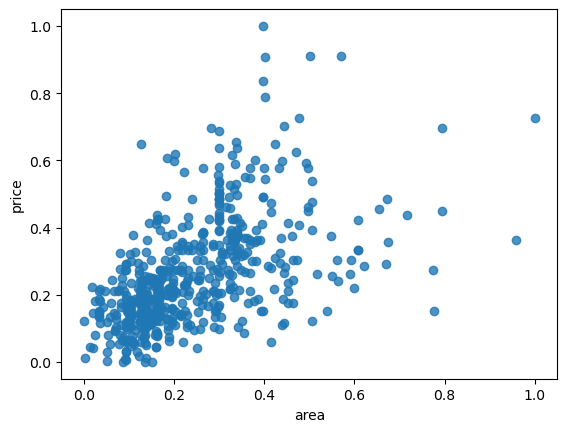

In [7]:
# visualise area-price relationship
sns.regplot(x="area", y="price", data=df, fit_reg=False)


<span style="color:#FF5F00"><b>AUFGABE 3:</b></span><br>
Machen Sie sich klar, was Sie im Plot sehen. Was bedeuten die Werte an den Achsen? Was bedeutet die Verteilung der Punkte entlang x und y? Sieht man einen Zusammenhang zwischen x und y?
</div>

<span style="color:green"><b>geben Sie nachfolgend Ihre schriftliche Antwort zur AUFGABE 3:</b></span><br>

Der Graph zeigt den Zusammenhang zwischen den skalierten Werten von Preis und Fläche.
Die Werte für beide Größen liegen nach der Skalierung zwischen 0 und 1, der Großteil der Werte scheint < 0.5 in beiden Eigenschaften zu sein.
Für beide Eigenschaften gilt, dass die Anzahl der Datenpunkte mit wachsendem Kennwert abnimmt.

Es deutet sich eine positive Lineare Abhängigkeit von Preis und Fläche an, welche mit zunehmenden Werten aber ungenauer wird. Bei kleinen Werten (< 0.4) ist der Zusammenhang noch recht deutlich zu sehen, wohingegen mit größer werdenden Werten der Zusammenhang mehr und mehr abnimmt. Die Punkte liegen dann zunehmend weiter von der imaginären Geraden entfernt, es bildet sich eine Art "Trichter".

Auffällig ist auch eine Punktgruppe bei `area = 0.3`, die entlang einer senkrechten Geraden verläuft.

In [8]:
# split into train and test
df_train, df_test = train_test_split(df, 
                                     train_size = 0.7, 
                                     test_size = 0.3, 
                                     random_state = 10)
print(len(df_train))
print(len(df_test))


381
164


### Experiments to Understand Overfitting

In this section, let's quickly go through some experiments to understand what overfitting looks like. We'll run some experiments using polynomial regression.

In [9]:
# split into X and y for both train and test sets
# reshaping is required since sklearn requires the data to be in shape
# (n, 1), not as a series of shape (n, )
X_train = df_train['area']
X_train = X_train.values.reshape(-1, 1)
y_train = df_train['price']

X_test = df_test['area']
X_test = X_test.values.reshape(-1, 1)
y_test = df_test['price']


### Polynomial Regression

You already know simple linear regression:

$y = \beta_0 + \beta_1 x_1$

In polynomial regression of degree $n$, we fit a curve of the form:

$y = \beta_0 + \beta_1 x_1 + \beta_2x_1^2 + \beta_3x_1^3 ... + \beta_nx_1^n$

In the experiment below, we have fitted polynomials of various degrees on the housing data and compared their performance on train and test sets.

In sklearn, polynomial features can be generated using the `PolynomialFeatures` class. Also, to perform `LinearRegression` and `PolynomialFeatures` in tandem, we will use the module `sklearn_pipeline` - it basically creates the features and feeds the output to the model (in that sequence).

<span style="color:#FF5F00"><b>AUFGABE 4:</b></span><br>
Wann ist der Einsatz einer polynomialen Regression sinnvoll, welche Vor- und Nachteile ergeben sich daraus im Vergleich zu einer einfachen linearen Regression?
</div>

<span style="color:green"><b>geben Sie nachfolgend Ihre schriftliche Antwort zur AUFGABE 4:</b></span><br>

Bei höhergradigen Zusammenhängen können polynomiale Regressionen diese besser abbilden. Ein parabelförmiger Zusammenhang lässt sich mit einer Funktion zweiten Grades besser annähern als mit einer Funktion ersten Grades (Lineare Funktion).

Allerdings neigen Annäherungen mit Funktionen höheren Grades dazu, außerhalb des im Training bekannten Wertebereichs schnell "auszubrechen" und deutliche Abweichungen von den eigentlichen Werten vorherzusagen.
Der Rechenaufwand sowie die Gefahr des Overfitting wird ebenfalls größer, wie in den nachfolgenden Graphen sichtbar. Außerdem sind Annäherungen mit größerem Polynomialgrad anfälliger für Ausreißer.

In [10]:
len(X_train)


381

Let's now predict the y labels (for both train and test sets) and store the predictions in a table. Each row of the table is one data point, each column is a value of $n$ (degree).

<table style="width:100%">
  <tr>
    <th>   </th>
    <th>degree-1</th>
    <th>degree-2</th> 
    <th>degree-3</th>
    <th>...</th>
    <th>degree-n</th>
  </tr>
  <tr>
    <th>x1</th>
  </tr>
  <tr>
    <th>x2</th>
  </tr>
   <tr>
    <th>x3</th>
    </tr>
    <tr>
    <th>...</th>
    </tr>
    <tr>
    <th>xn</th>
    </tr>
</table>

In [11]:
# fit multiple polynomial features
degrees = [1, 2, 3, 6, 10, 20]

# initialise y_train_pred and y_test_pred matrices to store the train and test predictions
# each row is a data point, each column a prediction using a polynomial of some degree
y_train_pred = np.zeros((len(X_train), len(degrees)))
y_test_pred = np.zeros((len(X_test), len(degrees)))

for i, degree in enumerate(degrees):
    
    # make pipeline: create features, then feed them to linear_reg model
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)
    
    # predict on test and train data
    # store the predictions of each degree in the corresponding column
    y_train_pred[:, i] = model.predict(X_train)
    y_test_pred[:, i] = model.predict(X_test)
    

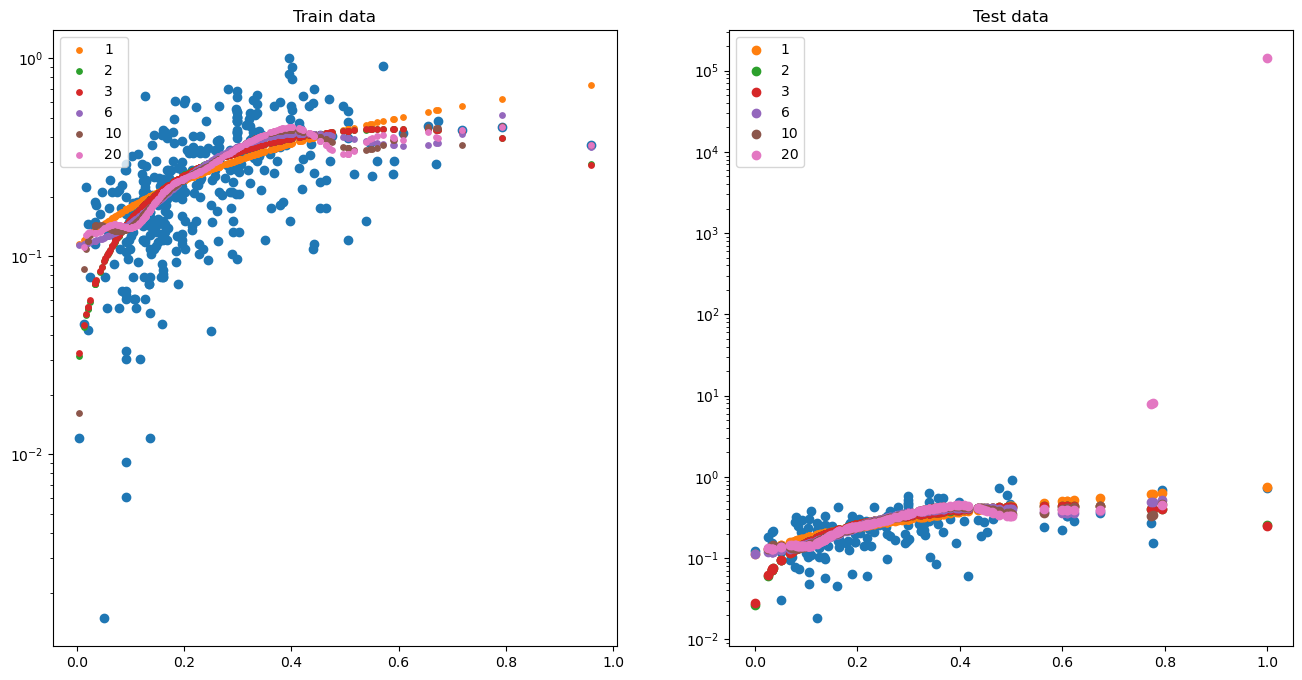

In [12]:
# visualise train and test predictions
# note that the y axis is on a log scale

plt.figure(figsize=(16, 8))

# train data
plt.subplot(121)
plt.scatter(X_train, y_train)
plt.yscale('log')
plt.title("Train data")
for i, degree in enumerate(degrees):    
    plt.scatter(X_train, y_train_pred[:, i], s=15, label=str(degree))
    plt.legend(loc='upper left')
    
# test data
plt.subplot(122)
plt.scatter(X_test, y_test)
plt.yscale('log')
plt.title("Test data")
for i, degree in enumerate(degrees):    
    plt.scatter(X_test, y_test_pred[:, i], label=str(degree))
    plt.legend(loc='upper left')


<span style="color:#FF5F00"><b>AUFGABE 5:</b></span><br>
Machen Sie sich klar, was Sie in den Plots sehen. Notieren Sie im Feld unten Ihre Beobachtungen.
<ul>
<li>Frage 1: In welchem Zusammenhang stehen die bunten Linien zu den blauen Punkten?</li>
<li>Frage 2: Was bedeuten die verschiedenen Farben der Linien?</li>
<li>Frage 3: Können Sie aus den Linien (im Feld "Test") irgendetwas sehen zu der Frage, welches Modell das "Beste" sein könnte?</li>
</ul>
</div>

<span style="color:green"><b>geben Sie nachfolgend Ihre schriftliche Antwort zur AUFGABE 5:</b></span><br>

**1.** Die blauen Punkte zeigen die tatsächlichen x- und y-Werte der Trainings- und Testdatensätze. Die Linien zeigen die vorhergesagten Werte.

**2.** Die bunten Linien zeigen die vorhergesagten Werte von Polynomialen Regressionen mit verschiedenen Graden.

**3.** Alle Funktionen mit Graden <= 3 nähern den Zusammenhang ohne offensichtliches Overfitting ganz gut an. Bei höheren Graden "schwankt" die Annäherung mehr und mehr und zeigt in Bereichen mit wenig Datenpunkten (z.B. x >= 0.7) viel Overfitting und Ausreißen.

Let us now evaluate the quality of our predictions by comparing predictions to true values. We use the R2 statistic for that.

In [13]:
# compare r2 for train and test sets (for all polynomial fits)
print("R-squared values: \n")

for i, degree in enumerate(degrees):
    train_r2 = round(sklearn.metrics.r2_score(y_train, y_train_pred[:, i]), 2)
    test_r2 = round(sklearn.metrics.r2_score(y_test, y_test_pred[:, i]), 2)
    print("Polynomial degree {0}: train score={1}, test score={2}".format(degree, 
                                                                         train_r2, 
                                                                         test_r2))


R-squared values: 

Polynomial degree 1: train score=0.29, test score=0.25
Polynomial degree 2: train score=0.34, test score=0.22
Polynomial degree 3: train score=0.34, test score=0.22
Polynomial degree 6: train score=0.36, test score=0.11
Polynomial degree 10: train score=0.37, test score=-108.76
Polynomial degree 20: train score=0.38, test score=-5612353618.59


<span style="color:#FF5F00"><b>AUFGABE 6:</b></span><br>

Schauen Sie sich die Zahlen mit den R squared values in Ruhe an. Bemerken Sie das absurde Verhalten?  

Was fällt Ihnen beim Vergleich der R-Squared-Werte der polynomialen Regression bei unterschiedlichen Graden auf, insbesondere bei Grad 10 und 20, und wie lässt sich dieses Verhalten im Hinblick auf Overfitting, negatives R² und die Generalisierungsfähigkeit des Modells erklären? Welche Grade erscheinen sinnvoll und welche führen zu instabilem, realitätsfernem Modellverhalten?
</div>

<span style="color:green"><b>geben Sie nachfolgend Ihre schriftliche Antwort zur AUFGABE 6:</b></span><br>

Wie oben bereits beschrieben, erzielen die Regressionen mit Grad <= 3 bessere Ergebnisse als die Regressionen höheren Grades.
Die höheren Grade erzielen konsequent bessere Ergebnisse auf den Trainingsdaten, liefern aber auf den unbekannten Testdaten deutlich schlechtere Ergebnisse - hier zeigt sich ganz klares **Overfitting**. Die Generalisierungsfähigkeit des Modells wird also schlechter.

Ein negatives R-Squared deutet auf eine besonders hohe **nicht aufgeklärte Varianz**. Das heißt, der Feher der vorhergesagten Werte ist sehr viel größer, als wenn man einfach den Mittelwert als "prediction" verwendet. 

### 1. Building a Model Without Cross-Validation

Let's now build a multiple regression model. First, let's build a vanilla MLR model without any cross-validation etc. 

In [14]:
# data preparation

# list of all the "yes-no" binary categorical variables
# we'll map yes to 1 and no to 0
binary_vars_list =  ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

# defining the map function
def binary_map(x):
    return x.map({'yes': 1, "no": 0})

# applying the function to the housing variables list
housing[binary_vars_list] = housing[binary_vars_list].apply(binary_map)
housing.head()


,price,area,garea,immo_score,build,ren,n_occ,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,8012,394,1932,2018,1,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,9429,907,1928,1921,4,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,10410,413,1973,1943,1,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,7725,860,2005,1981,2,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,8316,266,1937,2018,2,4,1,2,1,1,1,0,1,2,0,furnished


In [15]:
# 'dummy' variables
# get dummy variables for 'furnishingstatus' 
# also, drop the first column of the resulting df (since n-1 dummy vars suffice)
status = pd.get_dummies(housing['furnishingstatus'], drop_first = True)
status.head()


,semi-furnished,unfurnished
0,False,False
1,False,False
2,True,False
3,False,False
4,False,False


In [16]:
# concat the dummy variable df with the main df
housing = pd.concat([housing, status], axis = 1)
housing.head()


,price,area,garea,immo_score,build,ren,n_occ,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,semi-furnished,unfurnished
0,13300000,7420,8012,394,1932,2018,1,4,2,3,1,0,0,0,1,2,1,furnished,False,False
1,12250000,8960,9429,907,1928,1921,4,4,4,4,1,0,0,0,1,3,0,furnished,False,False
2,12250000,9960,10410,413,1973,1943,1,3,2,2,1,0,1,0,0,2,1,semi-furnished,True,False
3,12215000,7500,7725,860,2005,1981,2,4,2,2,1,0,1,0,1,3,1,furnished,False,False
4,11410000,7420,8316,266,1937,2018,2,4,1,2,1,1,1,0,1,2,0,furnished,False,False


In [17]:
# 'furnishingstatus' since we alreday have the dummy vars
housing.drop(['furnishingstatus'], axis = 1, inplace = True)
housing.head()


,price,area,garea,immo_score,build,ren,n_occ,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
0,13300000,7420,8012,394,1932,2018,1,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,9429,907,1928,1921,4,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,10410,413,1973,1943,1,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,7725,860,2005,1981,2,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,8316,266,1937,2018,2,4,1,2,1,1,1,0,1,2,0,False,False


#### Splitting Into Train and Test

<span style="color:#FF5F00"><b>AUFGABE 7:</b></span><br>

Das können Sie schon: erstellen Sie aus `housing` Test- und Trainingsdaten (70% Train, 30% Test).  Skalieren Sie anschließend alle numerischen Werte in Train mit einem `MinMaxScaler`!
</div>

In [18]:
# train-test 70-30 split
df_train, df_test = train_test_split(housing, test_size=0.3, train_size=0.7, random_state=42)

# rescale the features
scaler = MinMaxScaler()

# apply scaler() to all the numeric columns 
numeric_vars = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'price']
df_train[numeric_vars] = scaler.fit_transform(df_train[numeric_vars])
df_train.head()


,price,area,garea,immo_score,build,ren,n_occ,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
126,0.393333,0.378694,7398,196,1991,1934,2,0.4,0.0,0.0,1,0,1,0,0,0.666667,1,False,True
363,0.186667,0.132921,4219,423,1949,1982,2,0.2,0.0,0.0,1,0,0,1,0,0.000000,0,True,False
370,0.180000,0.180756,4722,342,1957,1958,5,0.2,0.0,0.0,1,0,0,0,1,0.666667,0,True,False
31,0.633333,0.367698,7110,54,1956,1973,5,0.4,0.0,1.0,1,0,0,0,1,0.666667,0,True,False
113,0.412667,0.547766,9731,268,1981,1947,0,0.4,0.0,0.0,1,0,1,0,0,0.666667,1,False,False


<span style="color:#FF5F00"><b>AUFGABE 8:</b></span><br>

Das können Sie auch schon: Übertragen Sie nun die Daten auf das Test-Set!
</div>

In [19]:
# apply rescaling to the test set also
df_test[numeric_vars] = scaler.transform(df_test[numeric_vars])
df_test.head()


,price,area,garea,immo_score,build,ren,n_occ,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
316,0.220000,0.292096,5964,766,1961,1955,1,0.6,0.333333,0.333333,0,0,1,0,0,0.333333,0,False,True
77,0.466667,0.333333,7268,682,1980,2016,4,0.4,0.333333,0.666667,1,0,0,0,1,0.000000,1,False,False
360,0.186667,0.164261,4990,532,1952,2013,4,0.2,0.000000,0.000000,1,0,0,0,0,0.000000,0,True,False
90,0.446667,0.230241,5607,489,1938,1969,2,0.4,0.000000,0.333333,1,0,0,0,1,0.000000,0,True,False
493,0.100000,0.158763,4693,372,1928,1985,4,0.4,0.000000,0.000000,1,0,0,0,0,0.000000,0,False,False


In [20]:
# divide into X_train, y_train, X_test, y_test
y_train = df_train.pop('price')
X_train = df_train

y_test = df_test.pop('price')
X_test = df_test


Note that we haven't rescaled the test set yet, which we'll need to do later while making predictions.

#### Using RFE 

Now, we have 13 predictor features. To build the model using Recursive Feature Elemination (RFE), we need to tell RFE how many features we want in the final model. It then runs a feature elimination algorithm. 

Note that the number of features to be used in the model is a **hyperparameter**.

In [21]:
# num of max features
len(X_train.columns)


18

In [22]:
# first model with an arbitrary choice of n_features
# running RFE with number of, let's say features=10

lm = LinearRegression()
lm.fit(X_train, y_train)

rfe = RFE(lm, n_features_to_select=10)             
rfe = rfe.fit(X_train, y_train)


In [23]:
# tuples of (feature name, whether selected, ranking)
# note that the 'rank' is > 1 for non-selected features
list(zip(X_train.columns,rfe.support_,rfe.ranking_))


[('area', np.True_, np.int64(1)),
 ('garea', np.False_, np.int64(8)),
 ('immo_score', np.False_, np.int64(7)),
 ('build', np.False_, np.int64(9)),
 ('ren', np.False_, np.int64(6)),
 ('n_occ', np.False_, np.int64(5)),
 ('bedrooms', np.True_, np.int64(1)),
 ('bathrooms', np.True_, np.int64(1)),
 ('stories', np.True_, np.int64(1)),
 ('mainroad', np.True_, np.int64(1)),
 ('guestroom', np.False_, np.int64(3)),
 ('basement', np.True_, np.int64(1)),
 ('hotwaterheating', np.True_, np.int64(1)),
 ('airconditioning', np.True_, np.int64(1)),
 ('parking', np.True_, np.int64(1)),
 ('prefarea', np.True_, np.int64(1)),
 ('semi-furnished', np.False_, np.int64(4)),
 ('unfurnished', np.False_, np.int64(2))]

In [24]:
# predict prices of X_test
y_pred = rfe.predict(X_test)

# evaluate the model on test set
r2 = sklearn.metrics.r2_score(y_test, y_pred)
print(r2)


0.6326237107391777


<span style="color:#FF5F00"><b>AUFGABE 9:</b></span><br>

Halten Sie kurz inne und überlegen Sie, was Sie hier sehen. Halten Sie unten fest, welches Subset die RFE jetzt eigentlich ausgewählt hat.
</div>

<span style="color:green"><b>geben Sie nachfolgend Ihre schriftliche Antwort zur AUFGABE 9:</b></span><br>  


Die folgenden Features sind übrig geblieben: 
- area
- bedrooms
- bathrooms
- stories
- mainroad
- basement
- hotwaterheating
- airconditioning
- parking
- prefarea

rausgefallen sind:
- garea
- immo_score
- build
- ren
- n_occ
- guestroom
- semi-furnished
- unfurnished

Die Größe der Häuser scheint besonders entscheidend, gleich fünf der zehn ausgewählten features sagen mind. indirekt etwas über die Größe aus (area, bedrooms, bathrooms, stories, basement). Annehmlichkeiten wie Parksituation und Heißwasser spielen eine Rolle ebenso wie die Lage (Mainroad, prefarea).

Moblierung, Bau- und Renovierungsjahr scheinen weniger wichtig für den Preis. Auch die Größe des Gartens (garea), die Anzahl der Vorbesitzer sowie der Immo-score haben wohl nicht ganz so viel Einfluss auf den Preis, wie die ausgewählten zehn features.

Mit den zehn ausgewählten features erreicht die trainierte lineare Regression einen R2-Wert von 0.63.

In [25]:
# try with another value of RFE
lm = LinearRegression()
lm.fit(X_train, y_train)

rfe = RFE(lm, n_features_to_select=6)             
rfe = rfe.fit(X_train, y_train)

# predict prices of X_test
y_pred = rfe.predict(X_test)
r2 = sklearn.metrics.r2_score(y_test, y_pred)
print(r2)


0.5793876022544776


<div class="alert alert-block alert-success">
<b>Arbeitsauftrag ohne Dokumentation</b> 
Wir haben jetzt also eine RFE mit n=6 und eine RFE mit n=10 gemacht. Welche ist besser?
</div>

## 2. Problems in the Current Approach

In train-test split, we have three options:
1. **Simply split into train and test**: But that way tuning a hyperparameter makes the model 'see' the test data (i.e. knowledge of test data leaks into the model)
2. **Split into train, validation, test sets**: Then the validation data would eat into the training set
3. **Cross-validation**: Split into train and test, and train multiple models by sampling the train set. Finally, just test once on the test set.


## 3. Cross-Validation: A Quick Recap

The following figure illustrates k-fold cross-validation with k=4. There are some other schemes to divide the training set, we'll look at them briefly later.

![](https://chkra.github.io/wikisys_lecture/workshops/08/08/img/kfold_cross.png)

## 4. Cross-Validation in sklearn

Let's now experiment with k-fold CV.

### 4.1 K-Fold CV

In [26]:
# k-fold CV (using all the 13 variables)
lm = LinearRegression()
scores = cross_val_score(lm, X_train, y_train, scoring='r2', cv=5)
scores      


array([0.68152045, 0.5006345 , 0.71725315, 0.58966393, 0.62492602])

In [27]:
# the other way of doing the same thing (more explicit)

# create a KFold object with 5 splits 
folds = KFold(n_splits = 5, shuffle = True, random_state = 100)
scores = cross_val_score(lm, X_train, y_train, scoring='r2', cv=folds)
scores   


array([0.51111646, 0.69390135, 0.67900575, 0.56038057, 0.76094114])

<span style="color:#FF5F00"><b>AUFGABE 10:</b></span><br>

Sie sollten 5 Werte in der Variable scores sehen. Überlegen Sie kurz: was bedeuten diese Werte?
</div>

<span style="color:green"><b>geben Sie nachfolgend Ihre schriftliche Antwort zur AUFGABE 10:</b></span><br>  


Die fünf scores sind Testergebnisse für jeden der Folds. Diese ergeben sich für jeden split, wenn das Modell auf den jeweils anderen trainiert und dann auf dem ausgewählten split getestet wird.

Die R2-Scores, die das Modell auf den 5 Folds erzielt hat, schwanken zwischen 0.5 und 0.77. Das zeigt sehr gut, dass der train-test split einen großen Einfluss auf die Test-Scores haben kann.

In [28]:
# can tune other metrics, such as MSE
scores = cross_val_score(lm, X_train, y_train, scoring='neg_mean_squared_error', cv=5)
scores


array([-0.01237103, -0.00724715, -0.00615453, -0.01297299, -0.01176846])

### 4.2 Hyperparameter Tuning Using Grid Search Cross-Validation

A common use of cross-validation is for tuning hyperparameters of a model. The most common technique is what is called **grid search** cross-validation.
![](https://chkra.github.io/wikisys_lecture/workshops/08/08/img/hyperparam.png)

In [29]:
# number of features in X_train
len(X_train.columns)


18

In [30]:
# step-1: create a cross-validation scheme
folds = KFold(n_splits = 5, shuffle = True, random_state = 100)

# step-2: specify range of hyperparameters to tune
hyper_params = [{'n_features_to_select': list(range(1, len(X_train.columns)))}]

# step-3: perform grid search
# 3.1 specify model
lm = LinearRegression()
lm.fit(X_train, y_train)
rfe = RFE(lm)             

# 3.2 call GridSearchCV()
model_cv = GridSearchCV(estimator = rfe, 
                        param_grid = hyper_params, 
                        scoring= 'r2', 
                        cv = folds, 
                        verbose = 1,
                        return_train_score=True)      

# fit the model
model_cv.fit(X_train, y_train)                  


Fitting 5 folds for each of 17 candidates, totalling 85 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RFE(estimator...rRegression())
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'n_features_to_select': [1, 2, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also disp

In [31]:
# cv results
cv_results = pd.DataFrame(model_cv.cv_results_)
cv_results


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_features_to_select,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.005962,0.000528,0.000867,0.000151,1,{'n_features_to_select': 1},0.016453,0.348437,0.256937,0.215405,...,0.249923,0.135533,17,0.332372,0.280547,0.313805,0.317536,0.280612,0.304975,0.020864
1,0.006031,0.000452,0.001029,0.000070,2,{'n_features_to_select': 2},0.330240,0.513153,0.447717,0.335526,...,0.457260,0.122585,16,0.504216,0.474290,0.496631,0.518734,0.452098,0.489194,0.023460
2,0.005289,0.000153,0.000887,0.000256,3,{'n_features_to_select': 3},0.429200,0.504473,0.484636,0.419231,...,0.503433,0.093807,15,0.553541,0.506512,0.557041,0.566789,0.514381,0.539653,0.024366
3,0.004640,0.000141,0.000736,0.000080,4,{'n_features_to_select': 4},0.389246,0.553000,0.509152,0.456696,...,0.521167,0.103823,14,0.595707,0.542543,0.591706,0.597440,0.549531,0.575385,0.024137
4,0.004285,0.000126,0.000681,0.000052,5,{'n_features_to_select': 5},0.338390,0.603372,0.573084,0.496512,...,0.550616,0.132497,13,0.643527,0.562362,0.640196,0.634892,0.603395,0.616874,0.030764
5,0.004102,0.000117,0.000676,0.000025,6,{'n_features_to_select': 6},0.413349,0.598217,0.616438,0.479048,...,0.567901,0.111476,12,0.680239,0.601466,0.660121,0.644610,0.607311,0.638749,0.030301
6,0.003966,0.000204,0.000686,0.000054,7,{'n_features_to_select': 7},0.444809,0.593894,0.633664,0.499784,...,0.592300,0.119042,11,0.696466,0.605374,0.677550,0.679076,0.628712,0.657436,0.034443
7,0.003581,0.000079,0.000677,0.000054,8,{'n_features_to_select': 8},0.444180,0.626591,0.648026,0.537158,...,0.610773,0.118179,10,0.696949,0.639610,0.681223,0.703228,0.649054,0.674013,0.025448
8,0.003442,0.000194,0.000686,0.000089,9,{'n_features_to_select': 9},0.448593,0.664728,0.652586,0.543393,...,0.620701,0.117180,9,0.703836,0.656858,0.687801,0.709576,0.657205,0.683055,0.022416
9,0.003146,0.000081,0.000666,0.000058,10,{'n_features_to_select': 10},0.475108,0.687688,0.655312,0.537474,...,0.630195,0.113028,8,0.706129,0.667621,0.695497,0.718627,0.658047,0.689184,0.022928


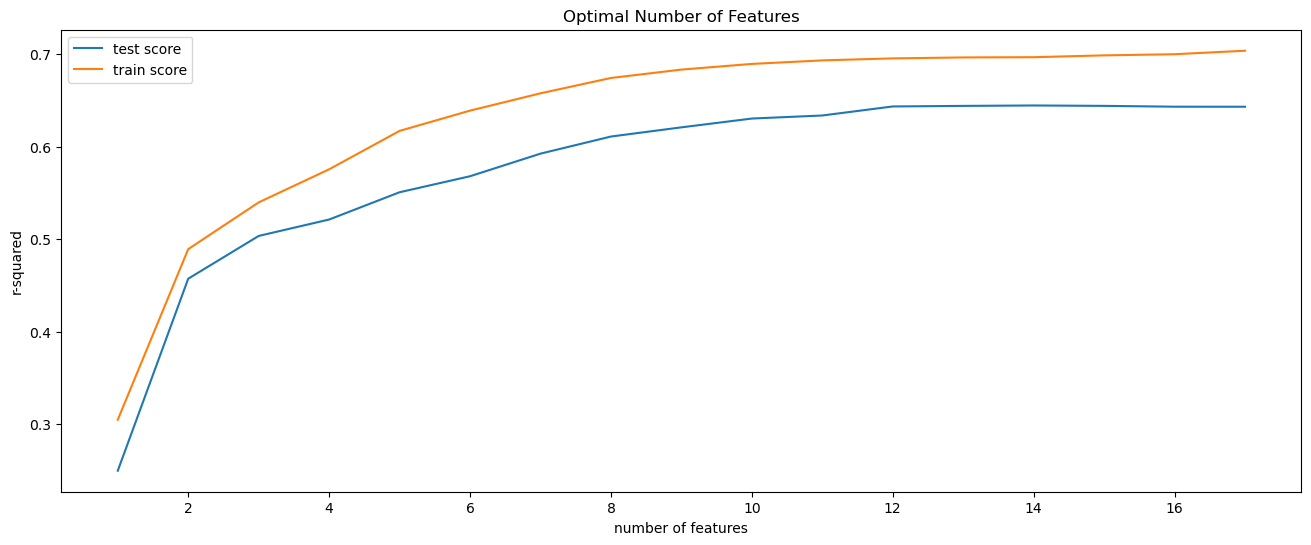

In [32]:
# plotting cv results
plt.figure(figsize=(16,6))

plt.plot(cv_results["param_n_features_to_select"], cv_results["mean_test_score"])
plt.plot(cv_results["param_n_features_to_select"], cv_results["mean_train_score"])
plt.xlabel('number of features')
plt.ylabel('r-squared')
plt.title("Optimal Number of Features")
plt.legend(['test score', 'train score'], loc='upper left')


<span style="color:#FF5F00"><b>AUFGABE 11:</b></span><br>

Schauen Sie auf die Tabelle. Was ist das beste Ergebnis und in welcher Spalte / welcher Zeile sehen Sie das?
</div>

PS: Vielleicht hilft [dieser Link](https://stackoverflow.com/questions/54608088/what-is-gridsearch-cv-results-could-any-explain-all-the-things-in-that-i-e-me) ?

<span style="color:green"><b>geben Sie nachfolgend Ihre schriftliche Antwort zur AUFGABE 11:</b></span><br>  


Das beste Ergebnis ist in `mean_test_score` zu sehen, in der Zeile mit `param_n_features_to_select = 14` und `rank_test_score = 1` oder in dem Attribut `best_estimator_` von model_cv.

Now we can choose the optimal value of number of features and build a final model.

<span style="color:#FF5F00"><b>AUFGABE 12:</b></span><br>


Nutzen Sie den Wert aus der letzten Frage und korrigieren Sie bei Bedarf den Wert der Variable n_features_optimal.
</div>

In [33]:
# final model
n_features_optimal = model_cv.best_params_['n_features_to_select']

print(n_features_optimal)

lm = LinearRegression()
lm.fit(X_train, y_train)

rfe = RFE(lm, n_features_to_select=n_features_optimal)             
rfe = rfe.fit(X_train, y_train)

# predict prices of X_test
y_pred = rfe.predict(X_test)
r2 = sklearn.metrics.r2_score(y_test, y_pred)
print(r2)


14
0.6466426283060689


Notice that the test score is very close to the 'mean test score' on the k-folds (about 60%). In general, the mean score estimated by CV will usually be a good estimate of the test score. 

### 4.3 Types of Cross-Validation Schemes


1. **K-Fold** cross-validation: Most common
2. **Leave One Out (LOO)**: Takes each data point as the 'test sample' once, and trains the model on the rest n-1 data points. Thus, it trains n total models.
    - Advantage: Utilises the data well since each model is trained on n-1 samples
    - Disadvantage: Computationally expensive
3. **Leave P-Out (LPO)**: Creat all possible splits after leaving p samples out. For n data points, there are (nCp) possibile train-test splits.
4. (**For classification problems**) **Stratified K-Fold**: Ensures that the relative class proportion is approximately preserved in each train and validation fold. Important when ther eis huge class imbalance (e.g. 98% good customers, 2% bad).

#### Additional Reading ####
The sklearn documentation enlists all CV schemes <a href="http://scikit-learn.org/stable/modules/cross_validation.html">here.</a>
